# GCE Models

In [1]:
import math as m

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vice

import paths

plt.style.use(paths.styles / 'notebook.mplstyle')

In [2]:
mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')
mwm_rgb

/var/folders/_s/lknhlnjn1g1cj388brpgztf80000gn/T/ipykernel_66309/610113364.py:1: DtypeWarning: Columns (44) have mixed types. Specify dtype option on import or set low_memory=False.
  mwm_rgb = pd.read_csv(paths.data / 'MWM' / 'MWM_RGB.csv')


,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,e,parallax,ra_y,dec_y,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,z_max,Rg
0,54381291,NaN,421495278551818624,421495278551818624,403218924,16384,tic_v8,25,27021597850714872,4291430952,...,NaN,0.132960,4.281347,56.316985,14.488654,15.619171,13.432241,1.114031,NaN,NaN
1,54381397,NaN,421505552113500800,421505552113500800,369831391,16384,tic_v8,25,27021597850723334,4291439436,...,NaN,0.229285,4.066874,56.422930,13.574258,14.658734,12.552815,1.032361,NaN,NaN
2,54381405,NaN,421506067509558016,421506067510359808,369831290,16384,tic_v8,25,27021597850724078,4291440182,...,NaN,0.287407,4.092194,56.472699,12.253111,13.457909,11.174816,1.058355,NaN,NaN
3,54381758,2M00204981+5625073,421540152367477248,421540152367477248,403307163,16385,gaia_dr3_source,31,63050394783216344,4291448641,...,NaN,0.137260,5.207570,56.418666,13.690668,14.897005,12.616476,1.025529,NaN,NaN
4,54381959,2M00224114+5636475,421557607115380608,421557607115380608,403393455,16025,gaia_dr3_source,31,63050394783222145,4291878516,...,0.176938,0.534588,5.671459,56.613157,11.369628,12.251155,10.450673,1.183852,0.205899,8.531358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178300,129060878,2M11484212-6220219,5334808943135705600,5334808943135705600,324668848,185355,gaia_dr3_source,31,63050395882762275,5762936654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178301,129060884,2M09110058-4849577,5326021096449688064,5326021096449688064,364057991,172356,gaia_dr3_source,31,63050395875982757,5802300216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178302,129060885,2M08333243-3911278,5529360241405866752,5529360241405866752,185021879,160694,gaia_dr3_source,31,63050395950945615,5800869040,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178303,129060909,2M13582184-6202236,5866253799616922112,5866253799616922112,325588166,185382,gaia_dr3_source,31,63050396108514375,5632820971,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
mwm_rgb_local = mwm_rgb[
    (mwm_rgb['gal_r'] >= 7) &
    (mwm_rgb['gal_r'] < 9) &
    (mwm_rgb['gal_z'].abs() < 2)
]
mwm_rgb_local

,sdss_id,sdss4_apogee_id,gaia_dr2_source_id,gaia_dr3_source_id,tic_v8_id,healpix,lead,version_id,catalogid,catalogid21,...,e,parallax,ra_y,dec_y,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,ruwe,z_max,Rg
5,54381962,NaN,421557744554456064,421557744554456064,403393481,16025,tic_v8,25,27021597851161095,4291878605,...,0.023527,0.821440,5.742822,56.604244,11.354103,12.103177,10.509450,1.051452,0.107297,8.766076
19,54382295,NaN,421589183715747968,421589183715747968,327577724,16024,tic_v8,25,27021597850733418,4291449550,...,0.082842,0.621352,4.838551,56.535746,12.989830,13.689755,12.176354,1.093702,0.253124,8.840263
27,54382700,2M00200721+5700122,421625909974353280,421625914277199872,406762101,15668,gaia_dr3_source,31,63050394783245110,4291624784,...,0.126596,0.953161,5.030085,57.003410,11.962486,12.695877,11.121562,6.407218,0.183795,7.756411
60,54383757,2M00290801+5640111,421706109904337024,421706109904337024,320047050,16027,gaia_dr3_source,31,63050394783273185,4291910754,...,0.098802,0.726696,7.283335,56.669774,12.007926,12.807559,11.132788,4.010105,0.136858,8.739005
73,54384509,2M00271056+5654556,421762352496488832,421762352496488832,319844954,15670,gaia_dr3_source,31,63050394783292573,4291900981,...,0.098081,0.637712,6.794001,56.915434,12.128599,12.845614,11.306450,1.005274,0.154093,8.455453
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178281,129060702,2M09103407-4845571,5326025391417031552,5326025391417031552,355665042,172356,gaia_dr3_source,31,63050395875983927,5802300960,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178287,129060768,2M09150089-4756448,5326450696258684032,5326450696258684032,461741387,171468,gaia_dr3_source,31,63050395876069826,5802236276,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178289,129060777,2M09120875-4832413,5326054081799907712,5326054081799907712,372916511,171914,gaia_dr3_source,31,63050395875989157,5802232075,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
178298,129060864,2M09093978-4751104,5326886175877017088,5326886175877017088,74380758,171016,gaia_dr3_source,31,63050395876148699,5802260041,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
output_dir = paths.data / 'onezone'
output_dir.mkdir(parents=True, exist_ok=True)

## s-process only

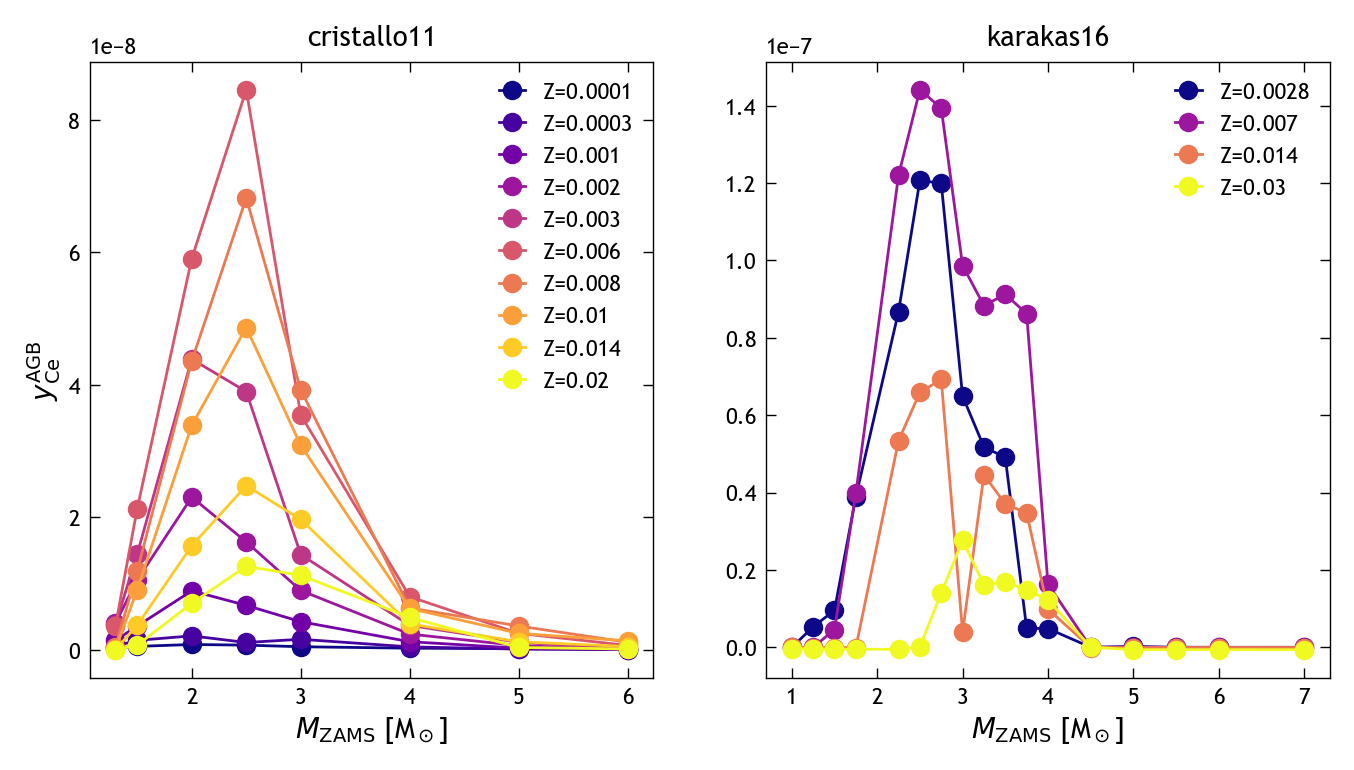

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

for j, study in enumerate(['cristallo11', 'karakas16']):
    grid, masses, metallicities = vice.yields.agb.grid('ce', study=study)
    cmap = plt.get_cmap('plasma')
    colors = cmap(np.linspace(0, 1, len(metallicities)))
    for i, z in enumerate(metallicities):
        yields = [grid[_][i] for _ in range(len(grid))]
        axs[j].plot(masses, yields, c=colors[i], marker='o', label=f'Z={z}')
    axs[j].legend()
    axs[j].set_title(study)
axs[0].set_xlabel(r'$M_{\rm ZAMS}$ [M$_\odot$]')
axs[1].set_xlabel(r'$M_{\rm ZAMS}$ [M$_\odot$]')
axs[0].set_ylabel(r'$y^{\rm AGB}_{\rm Ce}$')
plt.show()

In [31]:
vice.yields.ccsne.settings['mg'] = 0.0019
vice.yields.ccsne.settings['fe'] = 0.0012
vice.yields.ccsne.settings['ce'] = 0.
vice.yields.sneia.settings['mg'] = 0.
vice.yields.sneia.settings['fe'] = 0.0024
vice.yields.sneia.settings['ce'] = 0.
from vice.yields.agb import karakas16

In [32]:
dt = 0.01
tmax = 13.2
simtime = np.arange(0, tmax+dt, dt)

tau_rise = 2
timescale = 15
def sfr(time):
    return (1 - m.exp(-time / tau_rise)) * m.exp(-time/timescale)

In [33]:
outflows = [1, 2.5, 5]

for i, eta in enumerate(outflows):
    sz = vice.singlezone(
        name=str(output_dir / f'cerium-1p-eta{eta}'),
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=eta,
        delay=0.04,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn

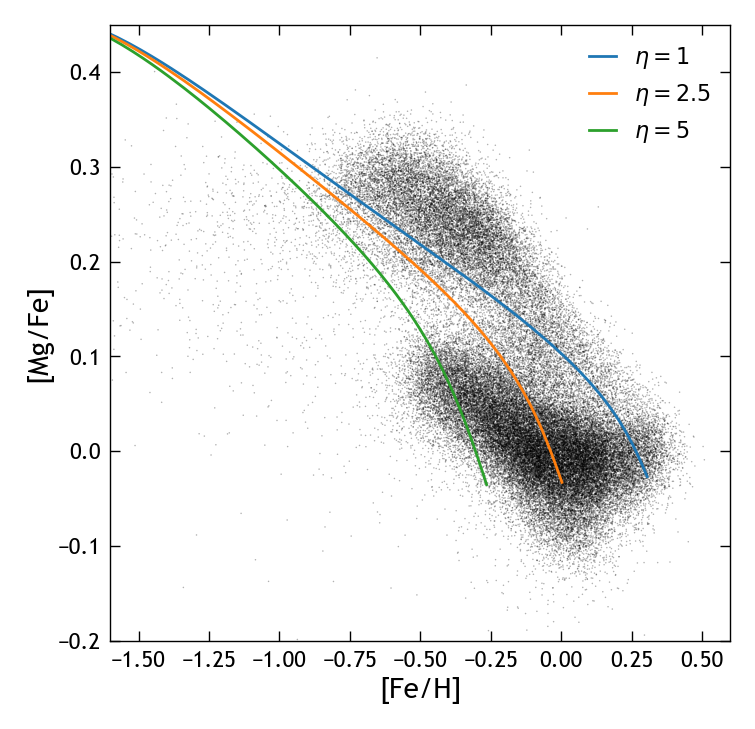

In [35]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['mg_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-1p-eta{eta}'))
    ax.plot(hist['[fe/h]'], hist['[mg/fe]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Mg/Fe]')
ax.set_xlim((-1.6, 0.6))
ax.set_ylim((-0.2, 0.45))
ax.legend()
plt.show()

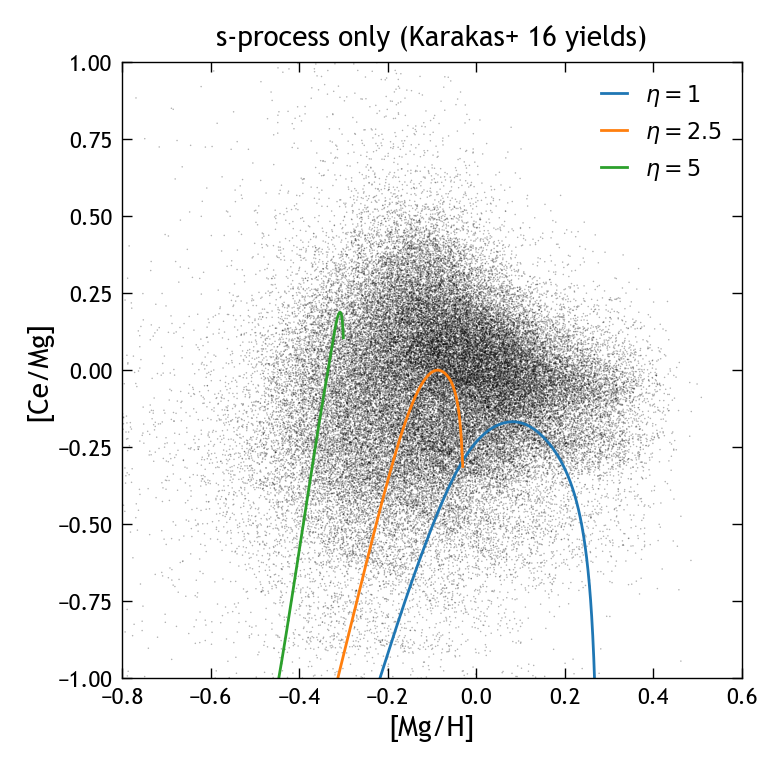

In [70]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-1p-eta{eta}'))
    ax.plot(hist['[mg/h]'], hist['[ce/mg]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
ax.set_title('s-process only (Karakas+ 16 yields)')
plt.show()

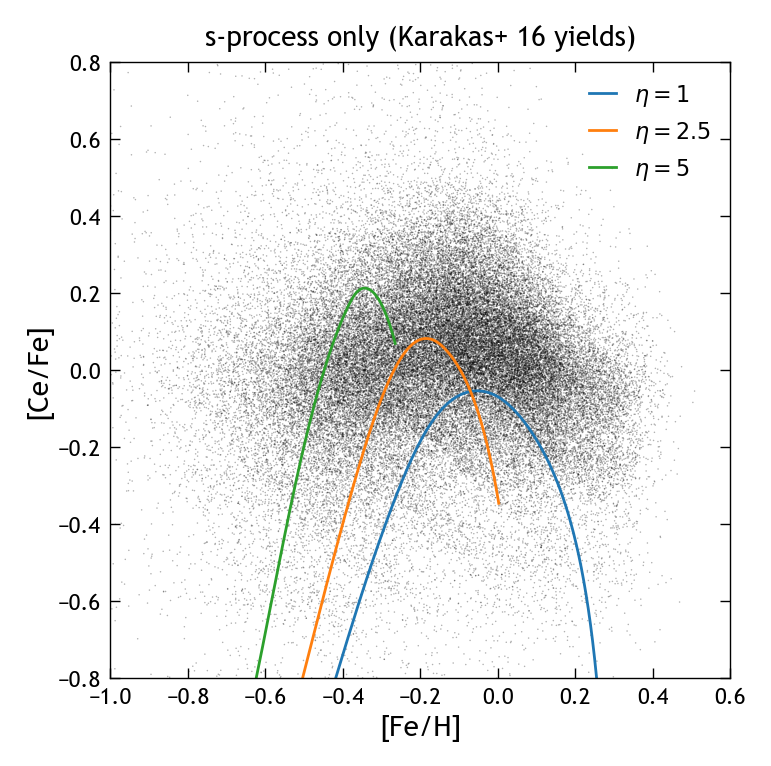

In [71]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['ce_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-1p-eta{eta}'))
    ax.plot(hist['[fe/h]'], hist['[ce/fe]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim((-1., 0.6))
ax.set_ylim((-0.8, 0.8))
ax.legend()
ax.set_title('s-process only (Karakas+ 16 yields)')
plt.show()

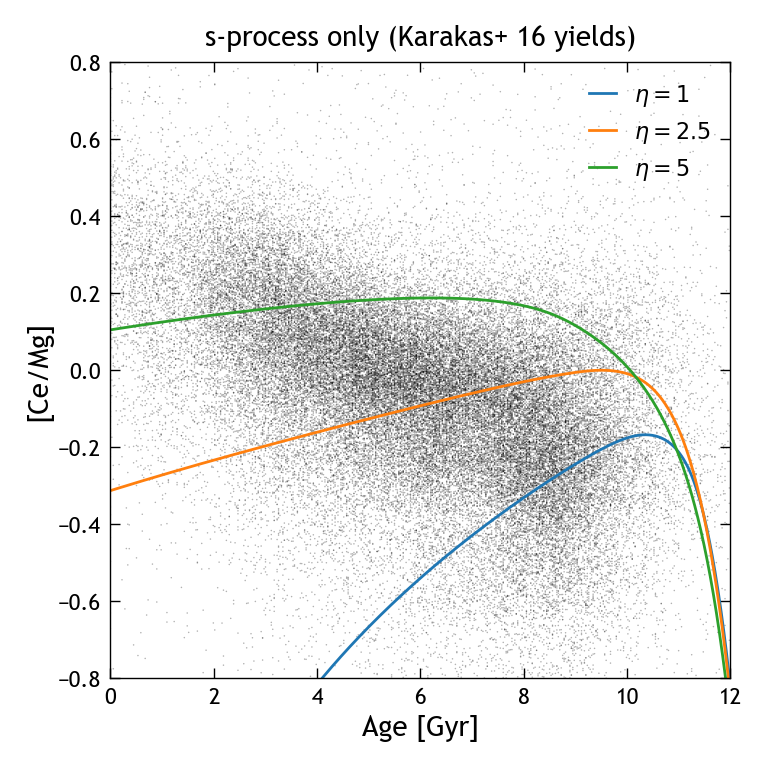

In [72]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['age'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-1p-eta{eta}'))
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend()
ax.set_title('s-process only (Karakas+ 16 yields)')
plt.show()

### Comparing different AGB yields

In [38]:
class amplified_agb(vice.yields.agb.interpolator): 
    def __init__(self, element, study = 'cristallo11', prefactor=3):
        self.prefactor = prefactor
        super().__init__(element, study=study)
    
    def __call__(self, mass, metallicity): 
        return self.prefactor * super().__call__(mass, metallicity) 

In [55]:
vice.yields.ccsne.settings['ce'] = 0
vice.yields.sneia.settings['ce'] = 0

studies = ['cristallo11', 'cristallo11', 'cristallo11', 'karakas16', 'karakas16']
prefactors = [1, 2, 3, 1, 2]
studies_dir = output_dir / 'agb_studies'
studies_dir.mkdir(parents=True, exist_ok=True)

tau_rise = 2
tau_sfh = 15
sfr = lambda t: (1 - m.exp(-t / tau_rise)) * m.exp(-t/tau_sfh)
for study, prefactor in zip(studies, prefactors):
    name = str(studies_dir / ('%s-%sx' % (study, prefactor)))
    vice.yields.agb.settings['ce'] = amplified_agb('ce', study=study, prefactor=prefactor)
    sz = vice.singlezone(
        name=name,
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=2.5,
        delay=0.04,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: VisibleRuntimeWarning: Functions of stellar mass and metallicity for asymptotic giant branch star yields may significantly increase the required integration time, especially for fine timestepping.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/pickles.py:305: UserWarning: Could not pickle function. The following attribute will not be saved with this output: ce
  warnings.warn

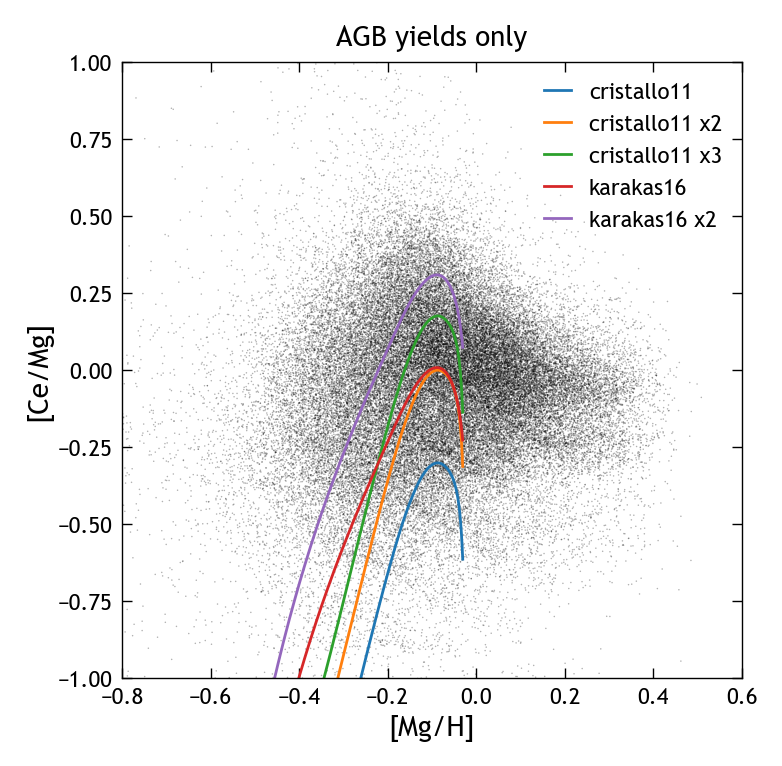

In [74]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for study, prefactor in zip(studies, prefactors):
    name = str(studies_dir / ('%s-%sx' % (study, prefactor)))
    hist = vice.history(name)
    label = study
    if prefactor > 1:
        label += ' x%s' % prefactor
    ax.plot(hist['[mg/h]'], hist['[ce/mg]'], label=label)
ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
ax.set_title('AGB yields only')
plt.show()

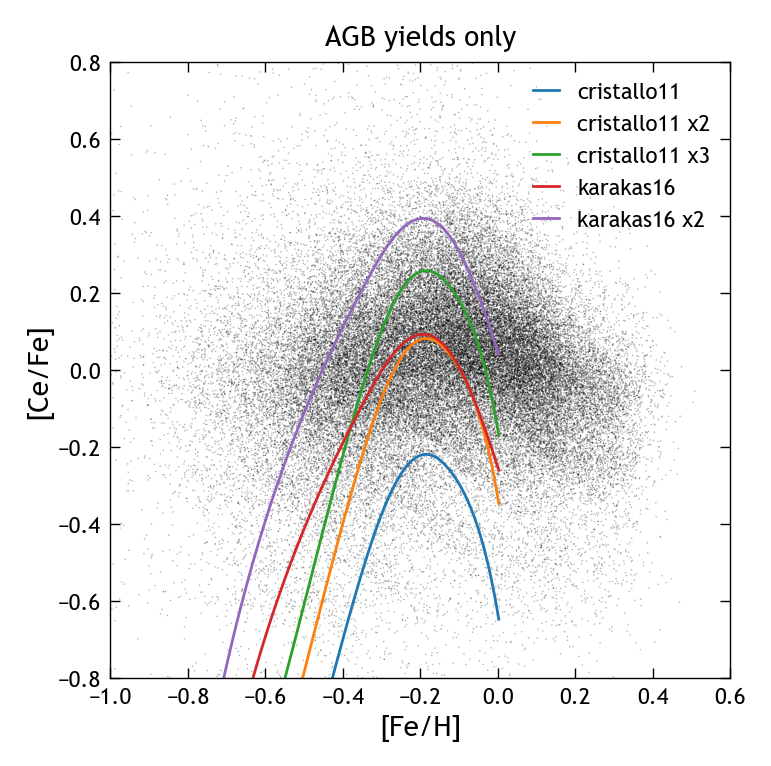

In [75]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['ce_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for study, prefactor in zip(studies, prefactors):
    name = str(studies_dir / ('%s-%sx' % (study, prefactor)))
    hist = vice.history(name)
    label = study
    if prefactor > 1:
        label += ' x%s' % prefactor
    ax.plot(hist['[fe/h]'], hist['[ce/fe]'], label=label)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim((-1., 0.6))
ax.set_ylim((-0.8, 0.8))
ax.legend()
ax.set_title('AGB yields only')
plt.show()

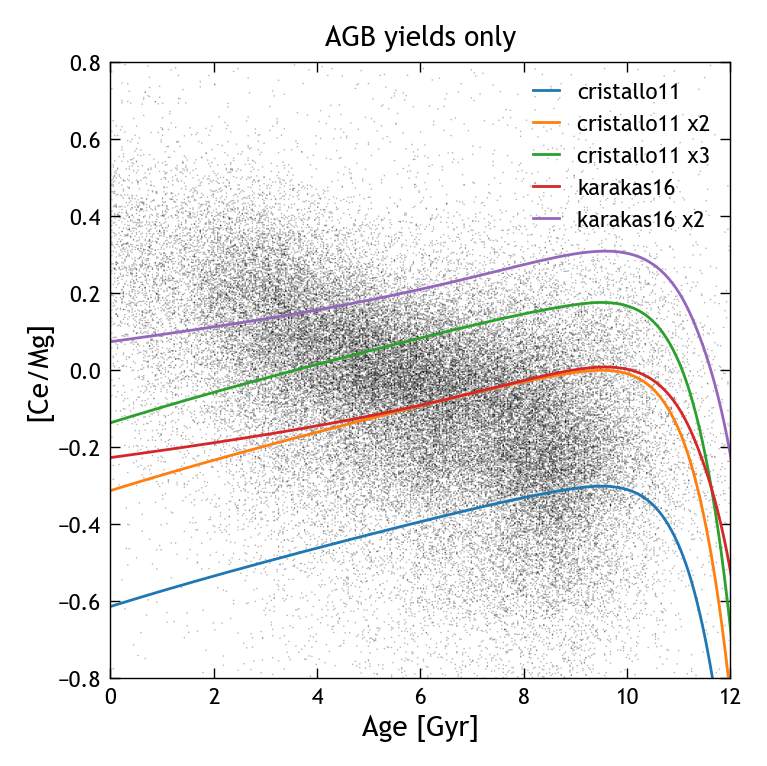

In [76]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['age'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for study, prefactor in zip(studies, prefactors):
    name = str(studies_dir / ('%s-%sx' % (study, prefactor)))
    hist = vice.history(name)
    label = study
    if prefactor > 1:
        label += ' x%s' % prefactor
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=label)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend()
ax.set_title('AGB yields only')
plt.show()

## Prompt r-process

In [59]:
vice.yields.ccsne.settings['ce'] = 3e-9
vice.yields.sneia.settings['ce'] = 0
vice.yields.agb.settings['ce'] = 'karakas16'

In [65]:
outflows = [1, 2.5, 5]
names = ['inner', 'solar', 'outer']

for i, eta in enumerate(outflows):
    sz = vice.singlezone(
        name=str(output_dir / f'cerium-2p-eta{eta}'),
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=eta,
        delay=0.04,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements track

[nan, -0.5427772617937892, -0.5427771696678068, -0.542777243932282, -0.5427772775661499, -0.5427772985416703, -0.5427773137555536, -0.5427710670925618, -0.5427596972717741, -0.542744660553911, -0.5427276255289988, -0.542709286235185, -0.5426901781422104, -0.542670012189058, -0.5426482492780862, -0.5426257821399495, -0.5426018035430362, -0.5425783175334948, -0.5425565375348038, -0.542539858043115, -0.5425300670733838, -0.5425299607694954, -0.5425406956703808, -0.542586086375715, -0.5427002817611936, -0.5429192465271201, -0.5432538772958448, -0.5436887916595107, -0.544193554812613, -0.5447305193744382, -0.5452618828865313, -0.5457578981214151, -0.5461948731933077, -0.5465535728678518, -0.5468191444459661, -0.5469799044621512, -0.5470263027786052, -0.5469506228023221, -0.5467466617805988, -0.5464098186353578, -0.5459365248876153, -0.545324468857043, -0.5445721810674792, -0.5436781128130712, -0.542641298160069, -0.5414598536012581, -0.5401311606658163, -0.538653863304969, -0.53702597841638

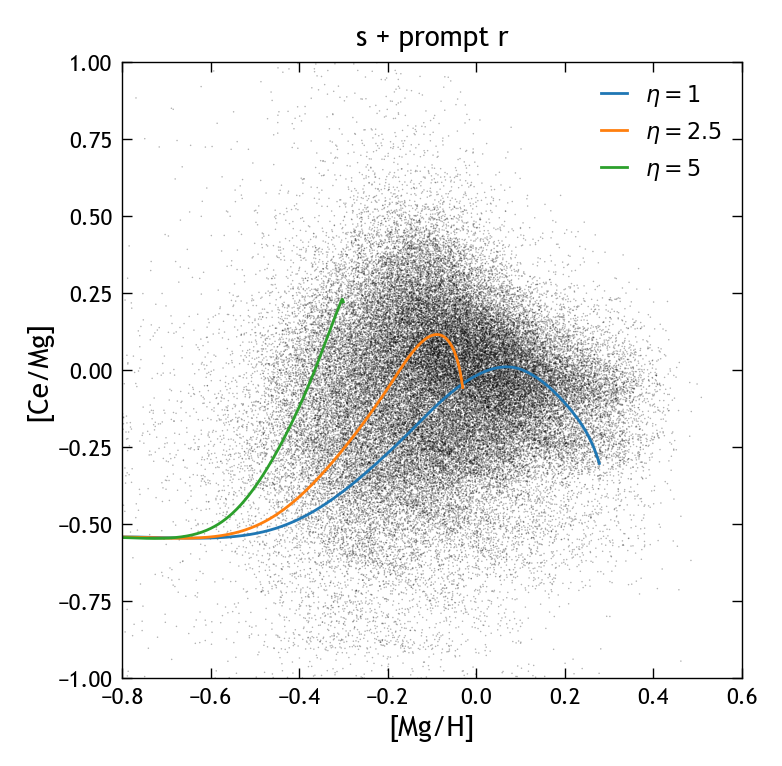

In [77]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-2p-eta{eta}'))
    print(hist['[ce/mg]'])  
    ax.plot(hist['[mg/h]'], hist['[ce/mg]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
ax.set_title('s + prompt r')
plt.show()

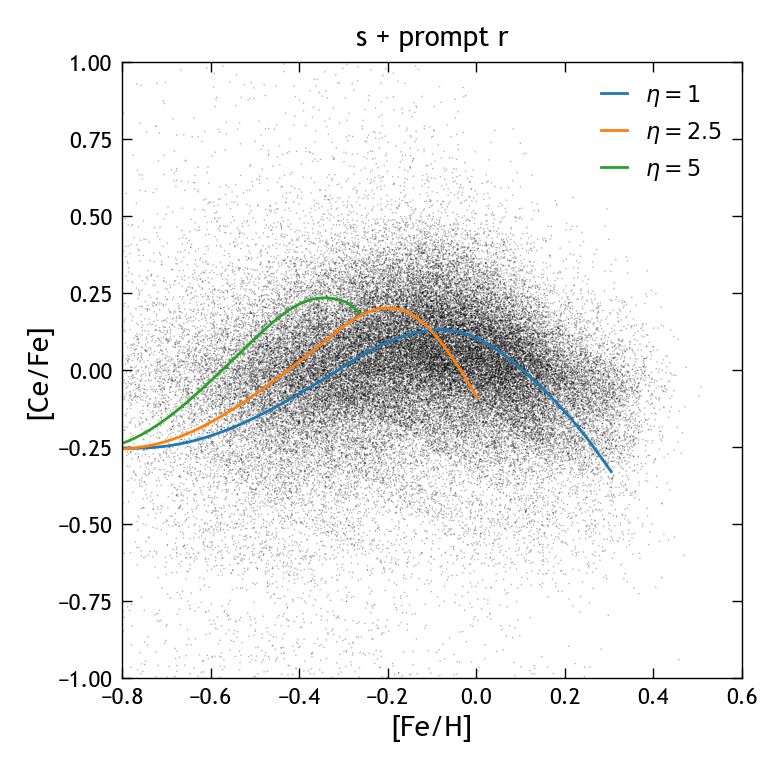

In [78]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['ce_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-2p-eta{eta}'))
    ax.plot(hist['[fe/h]'], hist['[ce/fe]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
ax.set_title('s + prompt r')
plt.show()

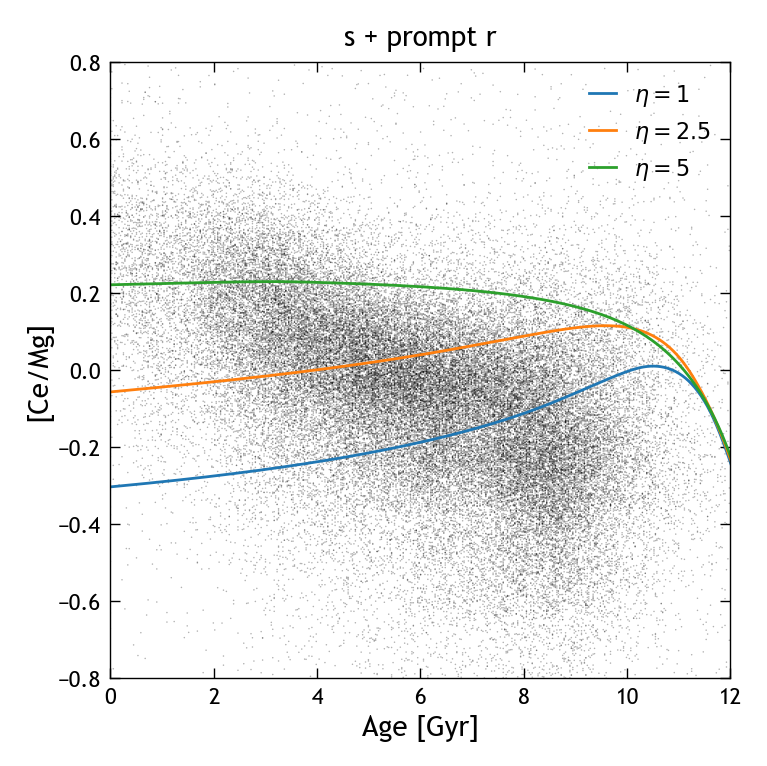

In [79]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['age'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-2p-eta{eta}'))
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend()
ax.set_title('s + prompt r')
plt.show()

## Pseudo-NSM contribution

In [97]:
vice.yields.ccsne.settings['ce'] = 3e-9
vice.yields.sneia.settings['ce'] = 3e-9
vice.yields.agb.settings['ce'] = 'karakas16'

In [98]:
outflows = [1, 2.5, 5]
for i, eta in enumerate(outflows):
    sz = vice.singlezone(
        name=str(output_dir / f'cerium-3p-eta{eta}'),
        func=sfr,
        mode='sfr',
        elements=('fe', 'mg', 'ce'),
        IMF='kroupa',
        eta=eta,
        delay=0.04,
        RIa='plaw',
        tau_star=2,
        dt=dt,
    )
    sz.run(simtime, overwrite=True)

/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements tracked by this simulation believed to be enriched by the r-process: ce 
In its current version, VICE is not designed to model enrichment via the r-process. These elements will likely be under-abundant in the output.
  return self.__c_version.run(output_times, capture = capture,
/opt/anaconda3/envs/chemical-clocks/lib/python3.12/site-packages/vice/core/singlezone/singlezone.py:1797: ScienceWarning: The following elements track

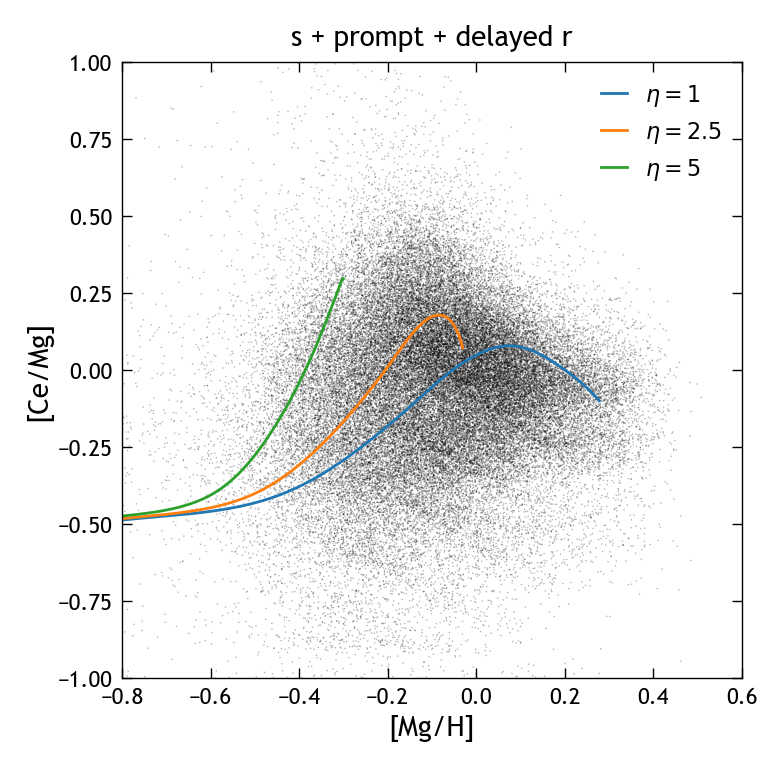

In [99]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['mg_h'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-3p-eta{eta}'))
    ax.plot(hist['[mg/h]'], hist['[ce/mg]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('[Mg/H]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
ax.set_title('s + prompt + delayed r')
plt.show()

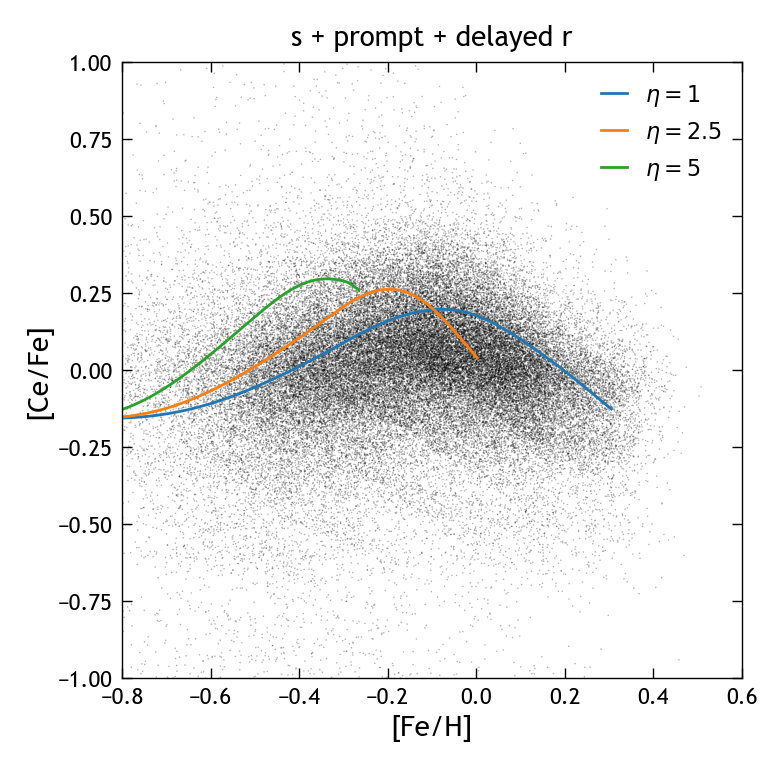

In [100]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['fe_h'], mwm_rgb_local['ce_fe'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-3p-eta{eta}'))
    ax.plot(hist['[fe/h]'], hist['[ce/fe]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('[Fe/H]')
ax.set_ylabel('[Ce/Fe]')
ax.set_xlim((-0.8, 0.6))
ax.set_ylim((-1, 1))
ax.legend()
ax.set_title('s + prompt + delayed r')
plt.show()

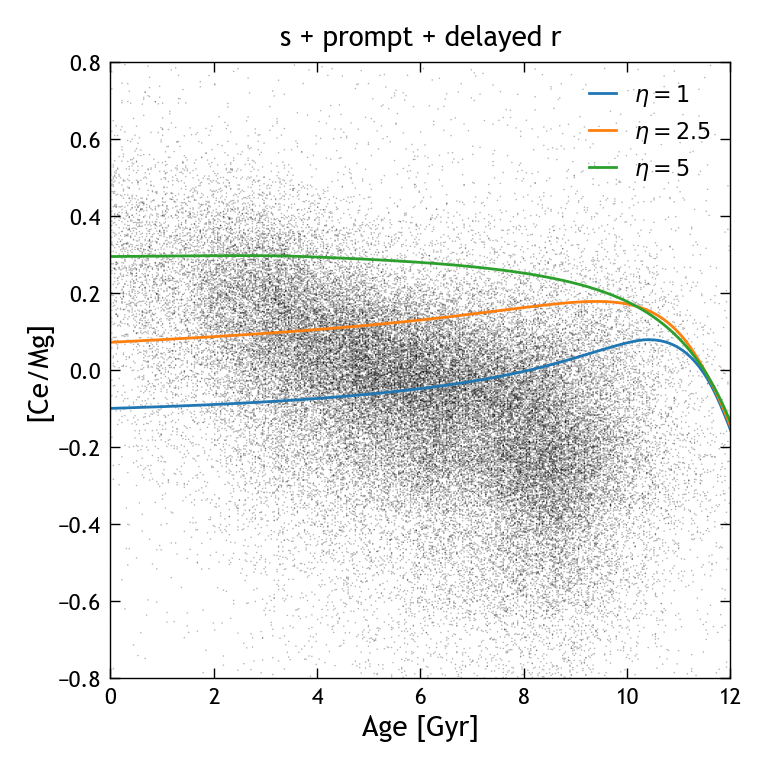

In [101]:
fig, ax = plt.subplots()
ax.scatter(mwm_rgb_local['age'], mwm_rgb_local['ce_mg'], 
           c='k', s=0.3, edgecolor='none', alpha=0.3)
for i, eta in enumerate(outflows):
    hist = vice.history(str(output_dir / f'cerium-3p-eta{eta}'))
    ax.plot(hist['lookback'], hist['[ce/mg]'], label=r'$\eta=%s$' % eta)
ax.set_xlabel('Age [Gyr]')
ax.set_ylabel('[Ce/Mg]')
ax.set_xlim((0, 12))
ax.set_ylim((-0.8, 0.8))
ax.legend()
ax.set_title('s + prompt + delayed r')
plt.show()